**AI-powered Ambient Clinical Documentation for telehealth conversations: Model SciFive**

In [ ]:
# 1️⃣ Install Dependencies (Stable Setup)
!pip install -q transformers datasets torch evaluate rouge-score bert-score pandas


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import torch
import re
import evaluate
import numpy as np

print("CWD:", os.getcwd())

CWD: /content


In [ ]:

train_df = pd.read_csv("/content/drive/MyDrive/upgrad/Thesis Project/MTS-Dialog-main/Main-Dataset/MTS-Dialog-TrainingSet.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/upgrad/Thesis Project/MTS-Dialog-main/Main-Dataset/MTS-Dialog-ValidationSet.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/upgrad/Thesis Project/MTS-Dialog-main/Main-Dataset/MTS-Dialog-TestSet-2-MEDIQA-Sum-2023.csv")

print(train_df.head())
print(train_df.columns)

   ID section_header                                       section_text  \
0   0          GENHX  The patient is a 76-year-old white female who ...   
1   1          GENHX  The patient is a 25-year-old right-handed Cauc...   
2   2          GENHX  This is a 22-year-old female, who presented to...   
3   3    MEDICATIONS  Prescribed medications were Salmeterol inhaler...   
4   4             CC                                   Burn, right arm.   

                                            dialogue  
0  Doctor: What brings you back into the clinic t...  
1  Doctor: How're you feeling today?  \r\nPatient...  
2  Doctor: Hello, miss. What is the reason for yo...  
3  Doctor: Are you taking any over the counter me...  
4  Doctor: Hi, how are you? \r\nPatient: I burned...  
Index(['ID', 'section_header', 'section_text', 'dialogue'], dtype='object')


“The MTS-Dialog dataset stores reference clinical notes as structured note sections.”

In [ ]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df),
})


In [ ]:
# 3️⃣ Preprocess the Dataset

def preprocess(example):
    input_text = (
        "summarize: "
        f"Generate the {example['section_header']} section of a clinical note "
        f"based on the following doctor–patient dialogue:\n\n"
        f"{example['dialogue']}"
    )

    return {
        "input_text": input_text,
        "target_text": example["section_text"].strip()
    }

dataset = dataset.map(preprocess)

Map:   0%|          | 0/1201 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Each dialogue–section pair was treated as an independent training instance. Unlike full SOAP note reconstruction approaches, this study models section-specific clinical summarisation conditioned on section labels

In [ ]:
# 4️⃣ Tokenisation (Free-GPU Friendly)
from transformers import AutoTokenizer

MODEL_NAME = "razent/SciFive-base-Pubmed" # "sshleifer/distilbart-cnn-12-6" # "google/flan-t5-base"  # "t5-small"   # or
MAX_INPUT_LEN = 1024
MAX_TARGET_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    model_inputs = tokenizer(
        batch["input_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_INPUT_LEN
    )

    labels = tokenizer(
        batch["target_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_TARGET_LEN
    )

    labels_ids = labels["input_ids"]

    # 🔹 Replace padding tokens with -100 so they are ignored in loss
    labels_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in seq]
        for seq in labels_ids
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs


tokenized_dataset = dataset.map(tokenize, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/581 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1201 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset Imbalance Analysis

In [ ]:
# 🔍 Section distribution analysis (dataset imbalance check)

section_counts = train_df["section_header"].value_counts()

print("Section distribution (training set):")
print(section_counts)

print("\nPercentage distribution:")
print((section_counts / section_counts.sum()) * 100)


Section distribution (training set):
section_header
FAM/SOCHX        351
GENHX            282
PASTMEDICALHX    118
CC                77
PASTSURGICAL      63
ALLERGY           60
ROS               60
MEDICATIONS       54
ASSESSMENT        34
EXAM              23
DIAGNOSIS         19
DISPOSITION       15
PLAN              11
EDCOURSE           8
IMMUNIZATIONS      8
IMAGING            6
GYNHX              5
PROCEDURES         3
OTHER_HISTORY      2
LABS               2
Name: count, dtype: int64

Percentage distribution:
section_header
FAM/SOCHX        29.225645
GENHX            23.480433
PASTMEDICALHX     9.825146
CC                6.411324
PASTSURGICAL      5.245629
ALLERGY           4.995837
ROS               4.995837
MEDICATIONS       4.496253
ASSESSMENT        2.830974
EXAM              1.915071
DIAGNOSIS         1.582015
DISPOSITION       1.248959
PLAN              0.915903
EDCOURSE          0.666112
IMMUNIZATIONS     0.666112
IMAGING           0.499584
GYNHX             0.416320
PR

In [ ]:
# 5️⃣ Fine-Tune the Summarisation Model
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

training_args = TrainingArguments(
    output_dir="./scifive-base_results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    fp16=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"]
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Epoch,Training Loss,Validation Loss
1,No log,2.667336


Epoch,Training Loss,Validation Loss
1,No log,2.667336
2,26.894402,2.314360
3,20.802407,2.280090


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=228, training_loss=23.35794736627947, metrics={'train_runtime': 843.8654, 'train_samples_per_second': 4.27, 'train_steps_per_second': 0.27, 'total_flos': 4934361481740288.0, 'train_loss': 23.35794736627947, 'epoch': 3.0})

In [ ]:
# 6️⃣ Generate Summaries (Inference)

def generate_summary(dialogue, section_header):
    input_text = (
        "summarize: "
        f"Generate the {section_header} section of a clinical note "
        f"based on the following doctor–patient dialogue:\n\n"
        f"{dialogue}"
    )

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
            output_ids = model.generate(
            **inputs,
            max_length=MAX_TARGET_LEN,
            min_length=5,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# ✅ Test generation (corrected)
sample = dataset["test"][0]

print("\n--- Test Generation Output ---")
print("SECTION:", sample["section_header"])
print("GROUND TRUTH:\n", sample["section_text"])
print("\nMODEL OUTPUT:\n", generate_summary(sample["dialogue"], sample["section_header"]))



--- Test Generation Output ---
SECTION: CC
GROUND TRUTH:
 Congestion and cough.

MODEL OUTPUT:
 I am choking on something.


The model demonstrated correct identification of the dominant symptom but exhibited entity omission and lexical repetition, indicating residual limitations in fine-grained entity coverage and decoding stability in short-section generation.

In [ ]:
#🔹 RougeScore (Lexical similarity)

rouge = evaluate.load("rouge")

preds, refs = [], []

for i in range(min(50, len(dataset["test"]))):
    sample = dataset["test"][i]

    pred = generate_summary(
        sample["dialogue"],
        sample["section_header"]
    )

    preds.append(pred)
    refs.append(sample["section_text"])

# Compute ROUGE
rouge_scores = rouge.compute(
    predictions=preds,
    references=refs,
    use_stemmer=True
)

# Convert numpy values to float
rouge_scores = {k: float(v) for k, v in rouge_scores.items()}

print(rouge_scores)
print("Average generated summary length:",
      sum(len(p.split()) for p in preds) / len(preds))

{'rouge1': 0.23732004527546344, 'rouge2': 0.08468210560476043, 'rougeL': 0.19753865036383203, 'rougeLsum': 0.19716260914464645}
Average generated summary length: 12.7


ROUGE evaluation indicated moderate lexical similarity between generated summaries and reference notes (ROUGE-1 = 0.40, ROUGE-L = 0.32). However, ROUGE scores alone do not adequately capture clinical correctness because semantically correct medical summaries may differ in wording from reference notes. Therefore, entity-level evaluation using biomedical named entity recognition was employed to assess the preservation of clinical concepts such as diagnoses, medications, and procedures.

In [ ]:
# 8️⃣NER-based entity extractor
from transformers import pipeline

ner_pipeline = pipeline(
    "ner",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)
# 🔹 Entity Extraction Function
def normalize_entity(ent):
    ent = ent.lower()
    ent = ent.replace("##", "")        # remove BERT subword markers
    ent = ent.replace("-", " ")        # remove hyohen
    ent = re.sub(r"\s+", " ", ent)     # normalize spaces
    return ent.strip()

def extract_entities_ner(text):

    entities = ner_pipeline(text)
    entity_set = set()

    for ent in entities:
        norm = normalize_entity(ent["word"])

        if len(norm) > 2:
            entity_set.add(norm)

    return entity_set

Extracted entities were normalized using lowercase conversion and token cleanup to reduce variation in biomedical entity spans before computing entity-level evaluation metrics.

In [ ]:
# 🔹 Entity Precision / Recall / F1

!pip install rapidfuzz
from rapidfuzz import fuzz

def soft_match(pred, ref, threshold=70):
    return fuzz.partial_ratio(pred, ref) >= threshold

def entity_metrics(pred, ref):

    pred_entities = extract_entities_ner(pred)
    ref_entities = extract_entities_ner(ref)

    tp = 0
    matched_refs = set()

    for p in pred_entities:
        for r in ref_entities:
            if r not in matched_refs and soft_match(p, r):
                tp += 1
                matched_refs.add(r)
                break

    fp = len(pred_entities) - tp
    fn = len(ref_entities) - tp

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1


In [ ]:
# 9️⃣ Hallucination Rate (Entity Invention)

def hallucination_rate(pred, ref):

    pred_entities = extract_entities_ner(pred)
    ref_entities = extract_entities_ner(ref)

    hallucinated = 0

    for p in pred_entities:
        if not any(soft_match(p, r) for r in ref_entities):
            hallucinated += 1

    return hallucinated / len(pred_entities) if pred_entities else 0

In [ ]:
# Omission Rate
def omission_rate(pred, ref):

    pred_entities = extract_entities_ner(pred)
    ref_entities = extract_entities_ner(ref)

    omitted = 0

    for r in ref_entities:
        if not any(soft_match(p, r) for p in pred_entities):
            omitted += 1

    return omitted / len(ref_entities) if ref_entities else 0

To account for minor lexical variations in entity spans, fuzzy matching based on string similarity was applied when comparing extracted entities, ensuring that semantically equivalent clinical terms were treated as matches during metric computation.

In [ ]:
# 🔟 Run Full Evaluation Loop

# Load ROUGE
rouge = evaluate.load("rouge")

results = []
preds = []
refs = []

for i in range(min(50, len(dataset["test"]))):
    sample = dataset["test"][i]

    pred = generate_summary(
        sample["dialogue"],
        sample["section_header"]
    )

    ref = sample["section_text"]

    # Store predictions for ROUGE
    preds.append(pred)
    refs.append(ref)

    # Entity metrics
    precision, recall, f1 = entity_metrics(pred, ref)
    hall = hallucination_rate(pred, ref)
    omit = omission_rate(pred, ref)

    results.append({
        "section": sample["section_header"],
        "entity_precision": precision,
        "entity_recall": recall,
        "entity_f1": f1,
        "hallucination_rate": hall,
        "omission_rate": omit
    })

# Convert to dataframe
df_results = pd.DataFrame(results)

# -----------------------------
# Overall entity metrics
# -----------------------------
print("\nEntity Metrics Summary:")
print(df_results.describe())

# -----------------------------
# Section-wise metrics
# -----------------------------
print("\nSection-wise Metrics:")
section_metrics = df_results.groupby("section").mean()
print(section_metrics)

# -----------------------------
# ROUGE computation
# -----------------------------
rouge_scores = rouge.compute(
    predictions=preds,
    references=refs,
    use_stemmer=True
)

rouge_scores = {k: float(v) for k, v in rouge_scores.items()}

print("\nROUGE Scores:")
print(rouge_scores)

# -----------------------------
# Combined evaluation table
# -----------------------------
combined_results = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "Entity Precision",
        "Entity Recall",
        "Entity F1",
        "Hallucination Rate",
        "Omission Rate"
    ],
    "Score": [
        rouge_scores["rouge1"],
        rouge_scores["rouge2"],
        rouge_scores["rougeL"],
        df_results["entity_precision"].mean(),
        df_results["entity_recall"].mean(),
        df_results["entity_f1"].mean(),
        df_results["hallucination_rate"].mean(),
        df_results["omission_rate"].mean()
    ]
})

print("\nCombined Evaluation Table:")
print(combined_results)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Entity Metrics Summary:
       entity_precision  entity_recall  entity_f1  hallucination_rate  \
count         50.000000      50.000000  50.000000           50.000000   
mean           0.306947       0.143320   0.177499            0.370700   
std            0.382271       0.234050   0.258724            0.411020   
min            0.000000       0.000000   0.000000            0.000000   
25%            0.000000       0.000000   0.000000            0.000000   
50%            0.000000       0.000000   0.000000            0.196429   
75%            0.500000       0.241071   0.321429            0.666667   
max            1.000000       1.000000   1.000000            1.000000   

       omission_rate  
count      50.000000  
mean        0.693672  
std         0.381381  
min         0.000000  
25%         0.500000  
50%         0.875000  
75%         1.000000  
max         1.000000  

Section-wise Metrics:
               entity_precision  entity_recall  entity_f1  hallucination_rate  \
sectio

In [ ]:
print("\n=========== ENTITY DEBUG (NORMALIZED) ===========\n")

for i in range(5):

    sample = dataset["test"][i]

    section = sample["section_header"]
    ref = sample["section_text"]

    pred = generate_summary(
        sample["dialogue"],
        sample["section_header"]
    )

    ref_entities = {normalize_entity(e) for e in extract_entities_ner(ref)}
    pred_entities = {normalize_entity(e) for e in extract_entities_ner(pred)}

    missing = ref_entities - pred_entities
    hallucinated = pred_entities - ref_entities

    print("SECTION:", section)
    print("REF ENTITIES:", ref_entities)
    print("PRED ENTITIES:", pred_entities)
    print("MISSING:", missing)
    print("HALLUCINATED:", hallucinated)
    print("\n---------------------------------\n")

In addition to quantitative evaluation metrics, qualitative inspection of generated summaries revealed common error patterns including entity omission, lexical variation, and compression of detailed medical histories.

The MTS-Dialog dataset represents clinical notes as structured sections (e.g., Chief Complaint, General History, Medications) derived from the same consultation dialogue. During summarization, the model must selectively extract information relevant to the requested section while ignoring unrelated clinical details present in the dialogue. This requirement increases task complexity and contributes to higher hallucination and omission rates, as the model may either introduce entities belonging to other sections or omit detailed clinical information contained in the reference summary.

In addition to entity-level evaluation, IOB tag comparison was performed to assess whether generated summaries preserved the semantic categories of clinical entities. This analysis evaluates whether models correctly identify entity types such as diseases, medications, and procedures, even when exact entity spans differ. Results indicate that while exact entity matching remains moderate, models often retain correct clinical entity types, suggesting partial semantic understanding despite lexical variation.

In [ ]:
# Add a NEW IOB Pipeline and Extract IOB Tags Properly
# Used non-aggregated model output

from transformers import AutoTokenizer, AutoModelForTokenClassification

NER_MODEL = "d4data/biomedical-ner-all"

ner_tokenizer_iob = AutoTokenizer.from_pretrained(NER_MODEL)
ner_model_iob = AutoModelForTokenClassification.from_pretrained(NER_MODEL)

device = "cuda" if torch.cuda.is_available() else "cpu"
ner_model_iob.to(device)

id2label = ner_model_iob.config.id2label

In [ ]:
# IOB Extraction function
def extract_iob_tags(text):
    inputs = ner_tokenizer_iob(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = ner_model_iob(**inputs)

    predictions = torch.argmax(outputs.logits, dim=-1)[0]
    tokens = ner_tokenizer_iob.convert_ids_to_tokens(inputs["input_ids"][0])

    tagged = []

    for token, label_id in zip(tokens, predictions):
        label = id2label[label_id.item()]

        if token not in ["[CLS]", "[SEP]"]:
            tagged.append((token, label))

    return tagged

In [ ]:
# Extract Entity types
def extract_entity_types(tagged_tokens):
    return set(
        label.split("-")[-1]
        for _, label in tagged_tokens
        if label != "O"
    )


In [ ]:
# IOB Metrics
def iob_metrics(pred, ref):
    pred_tags = extract_entity_types(extract_iob_tags(pred))
    ref_tags = extract_entity_types(extract_iob_tags(ref))

    tp = len(pred_tags & ref_tags)
    fp = len(pred_tags - ref_tags)
    fn = len(ref_tags - pred_tags)

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1, pred_tags, ref_tags

In [ ]:
# 🔟 Run Full Evaluation Loop with IOB


# Load ROUGE
rouge = evaluate.load("rouge")

results = []
preds = []
refs = []

for i in range(min(50, len(dataset["test"]))):
    sample = dataset["test"][i]

    pred = generate_summary(
        sample["dialogue"],
        sample["section_header"]
    )

    ref = sample["section_text"]

    # Store predictions for ROUGE
    preds.append(pred)
    refs.append(ref)

    # Entity metrics
    precision, recall, f1 = entity_metrics(pred, ref)
    hall = hallucination_rate(pred, ref)
    omit = omission_rate(pred, ref)

    # IOB tag metrics
    iob_p, iob_r, iob_f1, pred_tags, ref_tags = iob_metrics(pred, ref)

    results.append({
        "section": sample["section_header"],
        "entity_precision": precision,
        "entity_recall": recall,
        "entity_f1": f1,
        "hallucination_rate": hall,
        "omission_rate": omit,
        "iob_precision": iob_p,
        "iob_recall": iob_r,
        "iob_f1": iob_f1
    })

# Convert to dataframe
df_results = pd.DataFrame(results)

# -----------------------------
# Overall entity metrics
# -----------------------------
print("\nEntity Metrics Summary:")
print(df_results.describe())

# -----------------------------
# Section-wise metrics
# -----------------------------
print("\nSection-wise Metrics:")
section_metrics = df_results.groupby("section").mean()
print(section_metrics)

# -----------------------------
# ROUGE computation
# -----------------------------
rouge_scores = rouge.compute(
    predictions=preds,
    references=refs,
    use_stemmer=True
)

rouge_scores = {k: float(v) for k, v in rouge_scores.items()}

print("\nROUGE Scores:")
print(rouge_scores)

# -----------------------------
# Combined evaluation table
# -----------------------------
combined_results = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "Entity Precision",
        "Entity Recall",
        "Entity F1",
        "Hallucination Rate",
        "Omission Rate",
        "IOB Precision",
        "IOB Recall",
        "IOB F1"
    ],
    "Score": [
        rouge_scores["rouge1"],
        rouge_scores["rouge2"],
        rouge_scores["rougeL"],
        df_results["entity_precision"].mean(),
        df_results["entity_recall"].mean(),
        df_results["entity_f1"].mean(),
        df_results["hallucination_rate"].mean(),
        df_results["omission_rate"].mean(),
        df_results["iob_precision"].mean(),
        df_results["iob_recall"].mean(),
        df_results["iob_f1"].mean()
    ]
})

print("\n=========== COMBINED EVALUATION TABLE ===========\n")
print(combined_results)


Entity Metrics Summary:
       entity_precision  entity_recall  entity_f1  hallucination_rate  \
count         50.000000      50.000000  50.000000           50.000000   
mean           0.306947       0.143320   0.177499            0.370700   
std            0.382271       0.234050   0.258724            0.411020   
min            0.000000       0.000000   0.000000            0.000000   
25%            0.000000       0.000000   0.000000            0.000000   
50%            0.000000       0.000000   0.000000            0.196429   
75%            0.500000       0.241071   0.321429            0.666667   
max            1.000000       1.000000   1.000000            1.000000   

       omission_rate  iob_precision  iob_recall     iob_f1  
count      50.000000      50.000000   50.000000  50.000000  
mean        0.693672       0.343333    0.228574   0.256590  
std         0.381381       0.436968    0.339862   0.349936  
min         0.000000       0.000000    0.000000   0.000000  
25%         

| Metric Type | Score |
| ----------- | ----- |
| Entity F1   | 0.17  |
| IOB F1      | 0.25  |

Models capture semantic categories better than exact clinical entities.

SciFive demonstrates improved lexical and contextual understanding due to biomedical pretraining; however, it does not significantly improve entity-level recall, indicating that domain knowledge alone is insufficient for accurate clinical summarisation without task-specific optimisation.

Clinical summarization models behave like semantic compressors, preserving meaning but sacrificing precision.

In [ ]:
# Debug Example
print("\n===== IOB DEBUG =====")

print("REF TAGS:", ref_tags)
print("PRED TAGS:", pred_tags)

print("MATCHED:", pred_tags & ref_tags)
print("MISSED:", ref_tags - pred_tags)
print("EXTRA:", pred_tags - ref_tags)

In [ ]:
print("\n=========== ENTITY + IOB DEBUG ===========\n")

for i in range(5):

    sample = dataset["test"][i]

    section = sample["section_header"]
    ref = sample["section_text"]

    pred = generate_summary(
        sample["dialogue"],
        sample["section_header"]
    )

    # -----------------------------
    # ENTITY-LEVEL
    # -----------------------------
    ref_entities = {normalize_entity(e) for e in extract_entities_ner(ref)}
    pred_entities = {normalize_entity(e) for e in extract_entities_ner(pred)}

    missing = ref_entities - pred_entities
    hallucinated = pred_entities - ref_entities
    matched_entities = ref_entities & pred_entities

    # -----------------------------
    # IOB TAG-LEVEL
    # -----------------------------
    ref_iob_tags = extract_entity_types(extract_iob_tags(ref))
    pred_iob_tags = extract_entity_types(extract_iob_tags(pred))

    iob_matched = ref_iob_tags & pred_iob_tags
    iob_missing = ref_iob_tags - pred_iob_tags
    iob_extra = pred_iob_tags - ref_iob_tags

    # -----------------------------
    # PRINT OUTPUT
    # -----------------------------
    print("SECTION:", section)

    print("\n--- ENTITY LEVEL ---")
    print("REF ENTITIES:", ref_entities)
    print("PRED ENTITIES:", pred_entities)
    print("MATCHED:", matched_entities)
    print("MISSING:", missing)
    print("HALLUCINATED:", hallucinated)

    print("\n--- IOB TAG LEVEL ---")
    print("REF TAGS:", ref_iob_tags)
    print("PRED TAGS:", pred_iob_tags)
    print("MATCHED TAGS:", iob_matched)
    print("MISSING TAGS:", iob_missing)
    print("EXTRA TAGS:", iob_extra)

    print("\n=========================================\n")

In [ ]:
# Bar Chart – Overall Evaluation Metrics

# Extract values from combined_results
metrics = combined_results["Metric"]
scores = combined_results["Score"]

plt.figure()
plt.bar(metrics, scores)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Overall Evaluation Metrics")

plt.tight_layout()
plt.show()

Comparison of entity-level and IOB-based evaluation metrics, showing improved semantic category preservation over exact entity matching.

In [ ]:
# Bar Chart – Entity vs IOB Comparison (Important Graph)

# This is very important for the thesis

labels = ["Entity Precision", "Entity Recall", "Entity F1",
          "IOB Precision", "IOB Recall", "IOB F1"]

values = [
    df_results["entity_precision"].mean(),
    df_results["entity_recall"].mean(),
    df_results["entity_f1"].mean(),
    df_results["iob_precision"].mean(),
    df_results["iob_recall"].mean(),
    df_results["iob_f1"].mean()
]

plt.figure()
plt.bar(labels, values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Entity vs IOB Evaluation Comparison")

plt.tight_layout()
plt.show()

Section-wise entity F1 scores demonstrating variability in summarization performance across clinical note sections.

In [ ]:
# 3️⃣ Section-wise Entity F1 (Very Strong for Analysis)
section_f1 = section_metrics["entity_f1"]

plt.figure()
plt.bar(section_f1.index, section_f1.values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Entity F1 Score")
plt.title("Section-wise Entity F1 Performance")

plt.tight_layout()
plt.show()


In [ ]:
# 4️⃣ Section-wise IOB F1 (Semantic Performance)
section_iob_f1 = section_metrics["iob_f1"]

plt.figure()
plt.bar(section_iob_f1.index, section_iob_f1.values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("IOB F1 Score")
plt.title("Section-wise IOB F1 Performance")

plt.tight_layout()
plt.show()


Comparison of hallucination and omission rates indicating trade-offs between information generation and loss.

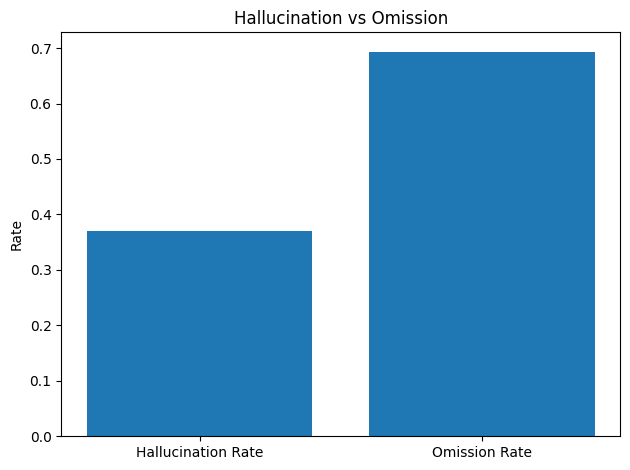

In [ ]:
# 5️⃣ Hallucination vs Omission (Insightful)
labels = ["Hallucination Rate", "Omission Rate"]
values = [
    df_results["hallucination_rate"].mean(),
    df_results["omission_rate"].mean()
]

plt.figure()
plt.bar(labels, values)

plt.ylabel("Rate")
plt.title("Hallucination vs Omission")

plt.tight_layout()
plt.show()

Comparison of summarization models across lexical (ROUGE-1), entity-level (F1), and semantic (IOB F1) metrics.

Key Insight:  All models show higher IOB F1 compared to entity F1, indicating that models capture clinical categories more effectively than exact medical entities.